# 02 - Experiment design: setting up the test before running it

This notebook contains what would happen before a single user sees the tip. It demonstrates:

1. **Power analysis** how many developers do we need to detect the effect we care about?
   (src/power_analysis.py)
2. **Assignment** split developers into arms in a way that is deterministic, balanced, and auditable. (src/experiment.py)

Model card:

| | |
|---|---|
| Unit of randomization | Developer account (one per person, not per project) |
| Primary metric | Active service after 30 days (retained_30d) |
| Baseline retention | ~61% (from pre-experiment cohorts) |
| Minimal detectable effect (MDE) | +2 pp |
| Power / significance | 80% at α = 0.05, two-sided |
| Enrollment window | 28 days |
| Guardrails | Onboarding completion, support ticket volume |


In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))

from src.power_analysis import (DEFAULT_ALPHA, DEFAULT_BASELINE, DEFAULT_POWER,
                                detectable_mde, mde_table, n_per_arm, power_at)
from src.experiment import (assign_dataframe, balance_check,
                            print_assignment_summary, srm_check)

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

print(f"Design constants: baseline={DEFAULT_BASELINE:.0%}, "
      f"alpha={DEFAULT_ALPHA}, power={DEFAULT_POWER:.0%}")


Design constants: baseline=61%, alpha=0.05, power=80%


## How many users do we need to detect a 2pp lift?

Caluclated with Cohen's h effect size with a normal approximation power solver (`statsmodels.NormalIndPower`), two-sided test and equal allocation.

In [2]:
target = n_per_arm(2.0)
print("How many users do we need to detect a 2pp lift?")
print(f"  N needed per arm : {target:,}")
print(f"  Total N needed   : {2 * target:,}")

print()
print("Required N by effect size:")
print(mde_table().to_string(index=False))


How many users do we need to detect a 2pp lift?
  N needed per arm : 9,245
  Total N needed   : 18,490

Required N by effect size:
 mde_pp  n_per_arm  total_n
    1.0      37167    74334
    1.5      16478    32956
    2.0       9245    18490
    3.0       4087     8174
    5.0       1454     2908
    8.0        557     1114


The relationship is drastic- halving the MDE almost quadruples the sample size. Detecting 1pp costs ~37k developers per arm; detecting 2pp costs ~9,245.

This is the single most important number in the project. Our simulated runs used 250 and 2,500 N/arm, all below it. Let's quantify exactly how bad that is.

  n=250/arm -> power = 7%
  smallest effect reliably detectable: 11.8pp
  n=2,500/arm -> power = 31%
  smallest effect reliably detectable: 3.8pp


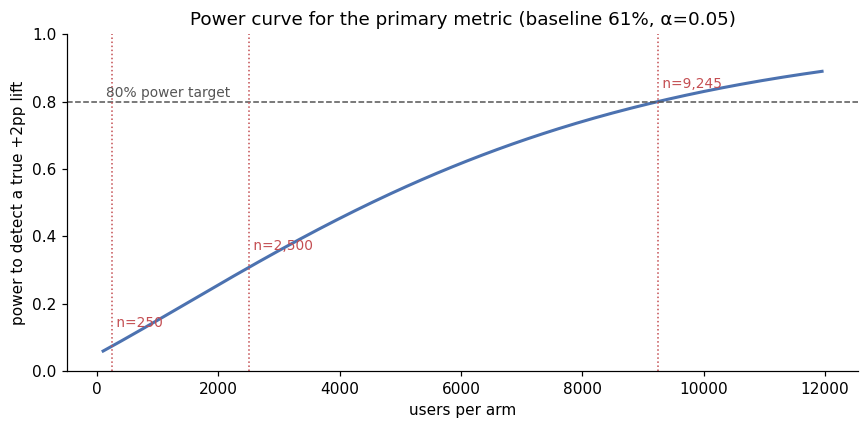

In [3]:
for n in (250, 2500):
    p = power_at(n, 2.0)
    print(f"  n={n:,}/arm -> power = {p:.0%}")
    print(f"  smallest effect reliably detectable: {detectable_mde(n):.1f}pp")

xs = np.arange(100, 12000, 50)
ys = [power_at(x, 2.0) for x in xs]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xs, ys, color="#4C72B0", lw=2)
ax.axhline(0.8, color="#555", ls="--", lw=1)
ax.text(150, 0.815, "80% power target", fontsize=9, color="#555")
for n, label_y in [(250, 0.13), (2500, 0.36), (9245, 0.84)]:
    ax.axvline(n, color="#C44E52", ls=":", lw=1)
    ax.text(n, label_y, f" n={n:,}", fontsize=9, color="#C44E52")
ax.set_xlabel("users per arm")
ax.set_ylabel("power to detect a true +2pp lift")
ax.set_title("Power curve for the primary metric (baseline 61%, α=0.05)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


Both Ns are signifantly underpowered. 

### Reading those numbers honestly

- **n=250/arm > 7% power.** If the tip truly works (+2pp), we detect it about 1 run in 14. 
  The smallest effect this cohort can reliably see is ~12pp — six times larger than the effect we actually expect.
- **n=2,500/arm > 31% power.** Better yet still worse than a coin flip.

Two things go wrong if you run it underpowered:
1. **A null result won't mean much.** At 31% power, "not significant" is what you'd expect even if the feature works, it doesn't indicate the effect is absent.
2. **A win will be overstated** Only large estimates clear p < 0.05 at this sample size, so any significant result is inflated by construction. Notebook 03 shows it: the N=500 run measured +6.6pp when the truth was +2.0pp.

At ~660 eligible signups per day (both arms combined), reaching 9,245/arm takes about 28 days, which is exactly why the enrollment window is 28 days.

## Assignment: same input, same arm, every time- deterministic, stateless, auditable

src/experiment.py picks each developer's arm by hashing their id together with a
per-experiment salt. That gives us three things:

- **Repeatable/ Idempotent** — a developer always lands in the same arm, so there's no assignment table to store or keep in sync.
- **Shared/ Stateless** — any service (onboarding, email, analytics) can work out the arm on its own and get the same answer.
- **Independent/ Isolated** — a new salt produces a fresh split, so the same person being in   treatment here says nothing about where they land in the next experiment.

The cells below assign the profile pool and run the two prelaunch checks of sample ratio mismatch (SRM) and covariate balance.

In [4]:
from data.simulate_cohort import normalize_profiles

profiles = normalize_profiles(pd.read_csv("../data/profiles.csv"))

profiles = assign_dataframe(profiles)   # salt: autoscaling_tip_onboarding_v1
print_assignment_summary(profiles)

Note: no developer_id column found — generated sequential ids.
      Assignment is a hash of this id, so ids (and therefore
      arms) will change if the profile file is reordered.
Assignment summary
  Control   : 2,480
  Treatment : 2,520
  Treatment share: 50.4%


In [5]:
print("Balance check") # we want all of these balanced
balance = balance_check(profiles)
print(balance.to_string(index=False))

srm_p = srm_check(profiles)
assert balance["balanced"].all() or srm_p < 0.001, \
    "imbalance detected " # imbalance with a valid split usually means a covariate leaked into assignment


Balance check
       covariate  control_mean  treatment_mean  difference  p_value  balanced
account_age_days   3139.218145     3087.994444  -51.223701 0.285448      True
      repo_count     20.955645       20.641270   -0.314375 0.371799      True
   commit_streak      9.726210        9.237698   -0.488511 0.485677      True


With random assignment we expect ~1 in 20 covariates to fail at p < 0.05 by chance, so a single marginal failure isn't alarming but a pattern of failures or failure together with SRM would be

## Takeaways

The following factors should be maintained before conducting analysis:

- Primary metric: `retained_30d`, defined in `dbt/models/marts/user_metrics.sql`
- MDE +2pp, baseline 61%, α = 0.05 two-sided, power 80% > 9,245 per arm 
- Enrollment window: 28 days
- Guardrails: onboarding completion rate, support tickets per user
- Segment analyses are exploratory only